# The Waffle House Capital of America

**Finding (plain English):** Georgia has more Waffle Houses than any other state —
**441 of the 2,005 operating U.S. locations (22.0%)**. That is more than the next
two states, Florida (188) and North Carolina (186), *combined* (374). The top five
states — Georgia, Florida, North Carolina, South Carolina, and Alabama — together
account for **57.2%** of all Waffle House locations.

*This notebook is written to be re-run top to bottom by a reviewer. It states the
claim first, documents the source, runs the data-quality checks, reproduces every
number step by step from the raw file, and ends with the limitations of the finding.*


## 1 · Data source

| | |
|---|---|
| **File** | `waffle_houses.csv` (in this repository) |
| **Rows** | 2,006 (one per Waffle House location record) |
| **Unit of analysis** | A single Waffle House location (restaurant), keyed by `Store Code` |
| **Provenance** | Waffle House public location directory (store list with address, coordinates, operator, hours) |
| **Key columns used here** | `Store Code`, `State` |
| **Full column reference** | See `DATA_DICTIONARY.md` in this repo |

Every column and the complete data-quality review live in `DATA_DICTIONARY.md`.
The checks below reproduce the parts of that review that bear on this finding, so
the notebook stands on its own.


## 2 · Setup — load the raw file

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the RAW file. Read everything as strings so IDs / ZIPs keep their exact
# formatting and nothing is silently coerced (e.g. the non-numeric 'WH_Museum').
df_raw = pd.read_csv("waffle_houses.csv", dtype=str)

print(f"Loaded {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head(3)

Loaded 2006 rows x 14 columns


,Store Code,Business Name,Address,City,State,Postal Code,Country,Latitude,Longitude,Phone Number,Website URL,Operated By,Online Order Link,Formatted Business Hours
0,100,Waffle House #100,2842 PANOLA RD,LITHONIA,GA,30058,US,33.704706,-84.169849,(770) 981-1914,https://locations.wafflehouse.com///lithonia-g...,"WAFFLE HOUSE, INC",https://order.wafflehouse.com/menu/waffle-hous...,Monday - Sunday| 24 hours
1,1000,Waffle House #1000,2850 E COLLEGE AVE,DECATUR,GA,30030,US,33.775215,-84.273744,(404) 294-8758,https://locations.wafflehouse.com///decatur-ga...,"WAFFLE HOUSE, INC",https://order.wafflehouse.com/menu/waffle-hous...,Monday - Sunday| 24 hours
2,1001,Waffle House #1001,12923 SHELBYVILLE RD,LOUISVILLE,KY,40243,US,38.243594,-85.513206,(502) 244-1005,https://locations.wafflehouse.com///louisville...,"FULLY OWNED SUBSIDIARY: MIDWEST WAFFLES, INC.",https://order.wafflehouse.com/menu/waffle-hous...,Monday - Sunday| 24 hours


## 3 · Data-quality checks (do this before trusting any number)

We verify the data is sound for a state-level count: no duplicate or missing
identifiers, and we identify the one record that is **not** an operating restaurant.

In [2]:
checks = {}

# Row count
checks["rows"] = len(df_raw)

# Duplicate Store Codes (the primary key) and fully duplicated rows
checks["duplicate_store_codes"] = int(df_raw["Store Code"].duplicated().sum())
checks["fully_duplicate_rows"]  = int(df_raw.duplicated().sum())

# Blank cells per column (only show columns that actually have blanks)
blanks = df_raw.isna().sum()
checks["columns_with_blanks"] = blanks[blanks > 0].to_dict()

# The 'State' column must be clean for this finding
checks["missing_state"]   = int(df_raw["State"].isna().sum())
checks["distinct_states"] = int(df_raw["State"].nunique())

# Identify non-numeric Store Codes (these are not regular numbered stores)
non_numeric = df_raw[~df_raw["Store Code"].str.fullmatch(r"\d+")]
checks["non_numeric_store_codes"] = non_numeric["Store Code"].tolist()

for k, v in checks.items():
    print(f"{k}: {v}")

rows: 2006
duplicate_store_codes: 0
fully_duplicate_rows: 0
columns_with_blanks: {'Operated By': 1, 'Online Order Link': 3, 'Formatted Business Hours': 2}
missing_state: 0
distinct_states: 25
non_numeric_store_codes: ['WH_Museum']


**Reading the checks:** there are **no duplicate Store Codes** and **no fully
duplicated rows**, and `State` has **no missing values** across **25 states**. The
only non-numeric `Store Code` is **`WH_Museum`** — the Waffle House Museum in
Decatur, GA, which is a tourist attraction, not an operating restaurant (it also
accounts for the blank `Operated By` / hours cells). We exclude it from the count
in the next step and show the effect explicitly.

## 4 · Reproduce the finding step by step

In [3]:
# Step 1 — exclude the non-restaurant museum row, with an explicit before/after.
before = len(df_raw)
df = df_raw[df_raw["Store Code"].str.fullmatch(r"\d+")].copy()
after = len(df)
print(f"Operating locations: {before} - {before - after} (museum) = {after}")

Operating locations: 2006 - 1 (museum) = 2005


In [4]:
# Step 2 — count locations per state and compute each state's share.
counts = df["State"].value_counts()
total = len(df)

by_state = (counts.rename("locations")
            .to_frame()
            .assign(share_pct=lambda t: (t["locations"] / total * 100).round(1)))
by_state.head(10)

,locations,share_pct
State,,
GA,441,22.0
FL,188,9.4
NC,186,9.3
SC,175,8.7
AL,156,7.8
TN,139,6.9
TX,127,6.3
LA,103,5.1
MS,88,4.4


In [5]:
# Step 3 — state the numbers behind the claim, each computed (not hard-coded).
top = by_state.index[0]
top_n = int(by_state.iloc[0]["locations"])
top_pct = by_state.iloc[0]["share_pct"]

second = int(by_state.iloc[1]["locations"])
third  = int(by_state.iloc[2]["locations"])
next_two = second + third

top5_share = round(by_state["locations"].head(5).sum() / total * 100, 1)

print(f"#1 state: {top} with {top_n} locations ({top_pct}% of {total})")
print(f"Next two ({by_state.index[1]} {second} + {by_state.index[2]} {third}) = {next_two}")
print(f"Is {top} ({top_n}) > next two combined ({next_two})? {top_n > next_two}")
print(f"Top 5 states' combined share: {top5_share}%")

#1 state: GA with 441 locations (22.0% of 2005)
Next two (FL 188 + NC 186) = 374
Is GA (441) > next two combined (374)? True
Top 5 states' combined share: 57.2%


## 5 · Chart — top 10 states (Georgia highlighted)

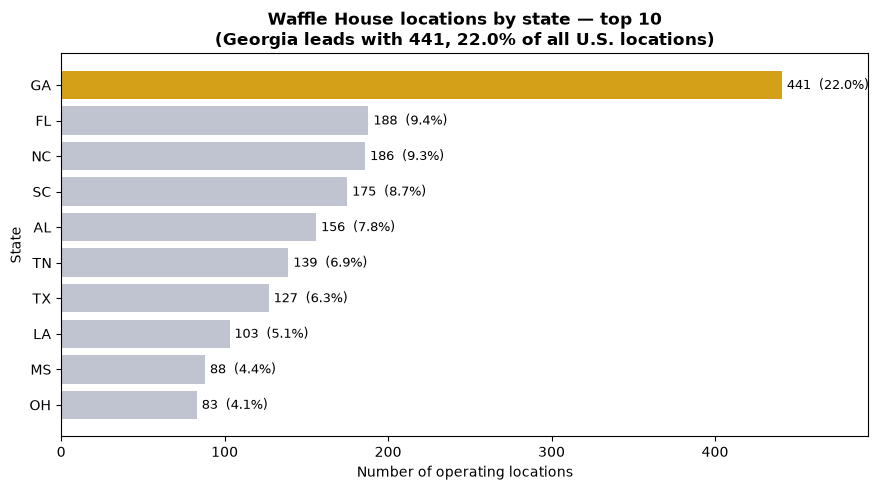

In [6]:
top10 = by_state.head(10).iloc[::-1]   # reverse so the largest sits at the top
colors = ["#d4a017" if s == top else "#bfc4d0" for s in top10.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10.index, top10["locations"], color=colors)
ax.set_title("Waffle House locations by state — top 10\n(Georgia leads with 441, 22.0% of all U.S. locations)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Number of operating locations")
ax.set_ylabel("State")

# data labels: count + share
for bar, (state, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f"{int(row['locations'])}  ({row['share_pct']}%)",
            va="center", fontsize=9)

ax.margins(x=0.12)
plt.tight_layout()
plt.show()

## 6 · Limitations

- **Snapshot in time.** This is a point-in-time location list; Waffle Houses open
  and close, so the exact counts will drift. The *ranking* (Georgia first) is large
  enough that small changes won't overturn it, but the precise 441 / 22.0% will.
- **Museum excluded.** We removed one non-restaurant record (`WH_Museum`). Including
  it would add a single location to Georgia and change nothing material.
- **Locations, not size.** The count measures *number of storefronts*, not revenue,
  customer traffic, square footage, or employees. "Most locations" ≠ "biggest market"
  by every measure.
- **Data-entry caveats (disclosed, not affecting this count).** Per
  `DATA_DICTIONARY.md`: 6 stores have low-precision coordinates and 8 have
  non-24h or blank hours. These affect mapping/hours analysis, not a state count.
- **Operator mix not considered here.** `Operated By` (corporate vs. subsidiary vs.
  franchise) is ignored for this finding; all operating locations are counted equally.

**Bottom line:** Georgia's lead in Waffle House locations is robust and reproducible
from the raw file; treat the exact figures as current-as-of-this-dataset, not permanent.
